In [1]:
# !pip install scikit-learn scipy matplotlib numpy pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris, load_wine, load_breast_cancer, make_moons, make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import sklearn
print('✅ All imports OK')
print(f'   sklearn : {sklearn.__version__}')

✅ All imports OK
   sklearn : 1.8.0


In [2]:
# ── 1.1  Manual Bayes Theorem ─────────────────────────────────────────────────
# Example: email spam detection
# Word 'win' appears in 80% of spam, 5% of ham
# 30% of emails are spam

def bayes(p_b_given_a, p_a, p_b_given_not_a):
    """P(A|B) = P(B|A)*P(A) / [P(B|A)*P(A) + P(B|notA)*P(notA)]"""
    p_not_a = 1 - p_a
    p_b = p_b_given_a * p_a + p_b_given_not_a * p_not_a
    return (p_b_given_a * p_a) / p_b

examples = [
    ('P(spam | word=win)',   0.80, 0.30, 0.05),
    ('P(spam | word=hello)', 0.20, 0.30, 0.60),
    ('P(disease | test+)',   0.95, 0.01, 0.05),  # medical test
]
print('Bayes Theorem examples:')
for name, p_b_a, p_a, p_b_na in examples:
    result = bayes(p_b_a, p_a, p_b_na)
    print(f'  {name:35s} = {result:.4f}')

Bayes Theorem examples:
  P(spam | word=win)                  = 0.8727
  P(spam | word=hello)                = 0.1250
  P(disease | test+)                  = 0.1610


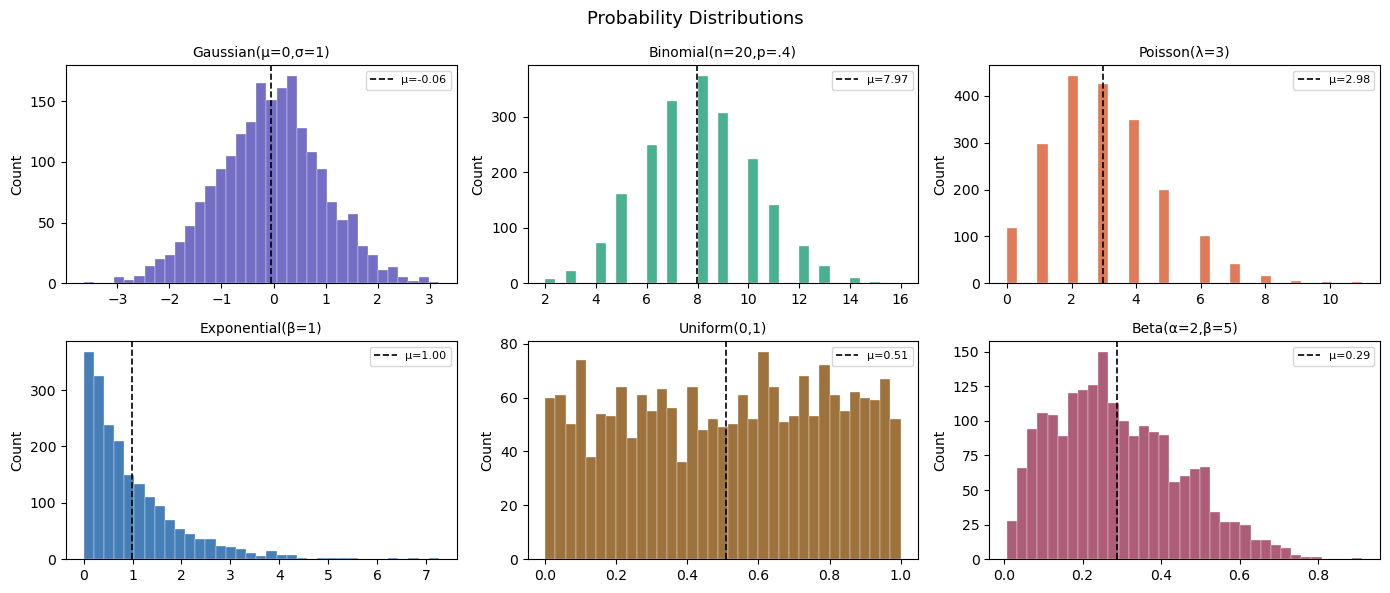

In [3]:
# ── 1.2  Key Probability Distributions ───────────────────────────────────────
rng = np.random.default_rng(42)
n   = 2000

samples = {
    'Gaussian(μ=0,σ=1)' : rng.normal(0, 1, n),
    'Binomial(n=20,p=.4)': rng.binomial(20, 0.4, n).astype(float),
    'Poisson(λ=3)'       : rng.poisson(3, n).astype(float),
    'Exponential(β=1)'   : rng.exponential(1, n),
    'Uniform(0,1)'       : rng.uniform(0, 1, n),
    'Beta(α=2,β=5)'      : rng.beta(2, 5, n),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
colors = ['#534AB7','#1D9E75','#D85A30','#185FA5','#854F0B','#993556']
for ax, (name, data), color in zip(axes.flatten(), samples.items(), colors):
    ax.hist(data, bins=35, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'μ={data.mean():.2f}')
    ax.legend(fontsize=8)
plt.suptitle('Probability Distributions', fontsize=13)
plt.tight_layout(); plt.show()

In [4]:
# ── 1.3  Gaussian Naive Bayes — How It Works ──────────────────────────────────
iris = load_iris(as_frame=True)
X, y = iris.data.values, iris.target

gnb = GaussianNB()
gnb.fit(X, y)

print('GaussianNB — Learned parameters:')
print(f'  Classes        : {gnb.classes_}')
print(f'  Class priors   : {gnb.class_prior_.round(3)}')
print(f'  Feature means  :\n{pd.DataFrame(gnb.theta_, columns=iris.feature_names, index=iris.target_names).round(2)}')
print(f'\nAccuracy on train: {gnb.score(X, y):.4f}')

# Log-probability prediction
sample = X[[0]]
log_probs = gnb.predict_log_proba(sample)[0]
probs     = gnb.predict_proba(sample)[0]
print(f'\nSample[0] probabilities  : {probs.round(4)}')
print(f'Sample[0] log-probs      : {log_probs.round(4)}')
print(f'Prediction               : {iris.target_names[gnb.predict(sample)[0]]}')

GaussianNB — Learned parameters:
  Classes        : [0 1 2]
  Class priors   : [0.333 0.333 0.333]
  Feature means  :
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                   5.01              3.43               1.46   
versicolor               5.94              2.77               4.26   
virginica                6.59              2.97               5.55   

            petal width (cm)  
setosa                  0.25  
versicolor              1.33  
virginica               2.03  

Accuracy on train: 0.9600

Sample[0] probabilities  : [1. 0. 0.]
Sample[0] log-probs      : [  0.     -41.1406 -57.9053]
Prediction               : setosa


In [5]:
# ── 1.4  Compare Naive Bayes Variants ────────────────────────────────────────
from sklearn.naive_bayes import BernoulliNB, ComplementNB

# Use Wine dataset (continuous features) for GaussianNB
Xw, yw = load_wine(return_X_y=True)

nb_models = {
    'GaussianNB'      : GaussianNB(),
    'GaussianNB+scaler': make_pipeline(StandardScaler(), GaussianNB()),
    'LogisticReg (ref)': make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)),
}
print('Naive Bayes comparison on Wine dataset (5-fold CV):')
for name, model in nb_models.items():
    sc = cross_val_score(model, Xw, yw, cv=5, scoring='accuracy')
    print(f'  {name:25s}: {sc.mean():.4f} ± {sc.std():.4f}')

Naive Bayes comparison on Wine dataset (5-fold CV):
  GaussianNB               : 0.9663 ± 0.0211
  GaussianNB+scaler        : 0.9663 ± 0.0211
  LogisticReg (ref)        : 0.9832 ± 0.0137


In [6]:
# ── 2.1  Independent t-test & Confidence Intervals ───────────────────────────
np.random.seed(42)
group_A = np.random.normal(50, 10, 100)   # control
group_B = np.random.normal(55, 10, 100)   # treatment

t_stat, p_val = stats.ttest_ind(group_A, group_B)
ci_A = stats.t.interval(0.95, df=len(group_A)-1,
                          loc=group_A.mean(), scale=stats.sem(group_A))
ci_B = stats.t.interval(0.95, df=len(group_B)-1,
                          loc=group_B.mean(), scale=stats.sem(group_B))

# Cohen's d effect size
pooled_std = np.sqrt((group_A.std()**2 + group_B.std()**2) / 2)
cohens_d   = (group_B.mean() - group_A.mean()) / pooled_std

print('=== Independent t-test Results ===')
print(f'Group A: mean={group_A.mean():.2f}, std={group_A.std():.2f}')
print(f'Group B: mean={group_B.mean():.2f}, std={group_B.std():.2f}')
print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_val:.6f}')
print(f'Significant : {p_val < 0.05} (α=0.05)')
print(f"95% CI (A)  : ({ci_A[0]:.2f}, {ci_A[1]:.2f})")
print(f"95% CI (B)  : ({ci_B[0]:.2f}, {ci_B[1]:.2f})")
print(f"Cohen's d   : {cohens_d:.4f} ({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'} effect)")

=== Independent t-test Results ===
Group A: mean=48.96, std=9.04
Group B: mean=55.22, std=9.49
t-statistic : -4.7547
p-value     : 0.000004
Significant : True (α=0.05)
95% CI (A)  : (47.16, 50.76)
95% CI (B)  : (53.33, 57.12)
Cohen's d   : 0.6758 (medium effect)


In [7]:
# ── 2.2  Chi-Square Test of Independence ─────────────────────────────────────
# Contingency table: gender vs product preference
observed = np.array([
    [40, 30, 20],   # Male:   ProductA, B, C
    [25, 45, 35],   # Female: ProductA, B, C
])
chi2, p_chi2, dof, expected = stats.chi2_contingency(observed)

print('=== Chi-Square Test of Independence ===')
print(f'Chi2 statistic : {chi2:.4f}')
print(f'p-value        : {p_chi2:.6f}')
print(f'Degrees of freedom : {dof}')
print(f'Independent    : {p_chi2 > 0.05}  (p>0.05 → independent)')
print('Expected frequencies:')
print(pd.DataFrame(expected.round(1),
                   index=['Male','Female'],
                   columns=['Product A','Product B','Product C']))

=== Chi-Square Test of Independence ===
Chi2 statistic : 9.4545
p-value        : 0.008851
Degrees of freedom : 2
Independent    : False  (p>0.05 → independent)
Expected frequencies:
        Product A  Product B  Product C
Male         30.0       34.6       25.4
Female       35.0       40.4       29.6


Sample mean         : 60.3858
Bootstrap 95% CI    : (57.7933, 62.8985)
Analytical 95% CI   : (57.8009, 62.9708)


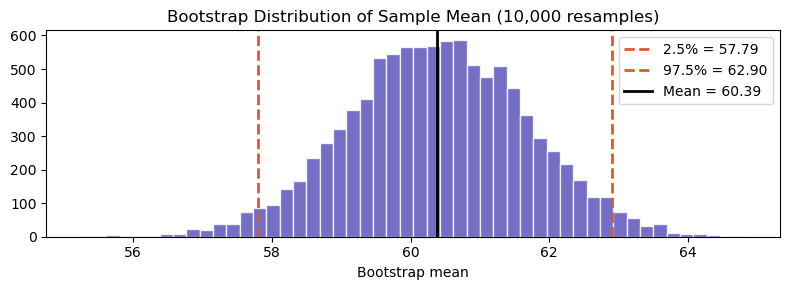

In [8]:
# ── 2.3  Bootstrap Confidence Interval ───────────────────────────────────────
rng = np.random.default_rng(42)
data = rng.normal(60, 15, 80)   # sample of 80 observations

# Bootstrap 10,000 resamples
bootstrap_means = [
    rng.choice(data, size=len(data), replace=True).mean()
    for _ in range(10_000)
]
bs_lo, bs_hi = np.percentile(bootstrap_means, [2.5, 97.5])

# Compare with analytical CI
anal_ci = stats.t.interval(0.95, df=len(data)-1, loc=data.mean(), scale=stats.sem(data))

print(f'Sample mean         : {data.mean():.4f}')
print(f'Bootstrap 95% CI    : ({bs_lo:.4f}, {bs_hi:.4f})')
print(f'Analytical 95% CI   : ({anal_ci[0]:.4f}, {anal_ci[1]:.4f})')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(bootstrap_means, bins=50, color='#534AB7', alpha=0.8, edgecolor='white')
ax.axvline(bs_lo, color='#D85A30', linestyle='--', linewidth=2, label=f'2.5% = {bs_lo:.2f}')
ax.axvline(bs_hi, color='#D85A30', linestyle='--', linewidth=2, label=f'97.5% = {bs_hi:.2f}')
ax.axvline(data.mean(), color='black', linewidth=2, label=f'Mean = {data.mean():.2f}')
ax.set_title('Bootstrap Distribution of Sample Mean (10,000 resamples)')
ax.set_xlabel('Bootstrap mean'); ax.legend()
plt.tight_layout(); plt.show()

In [9]:
# ── 2.4  Normality & Multiple Testing ────────────────────────────────────────
rng = np.random.default_rng(0)
normal_data = rng.normal(0, 1, 200)
skewed_data = rng.exponential(1, 200)

for name, d in [('Normal data', normal_data), ('Skewed data', skewed_data)]:
    stat, p = stats.shapiro(d[:50])   # Shapiro-Wilk (use first 50 for speed)
    ks_stat, ks_p = stats.kstest(d, 'norm', args=(d.mean(), d.std()))
    print(f'{name}:')
    print(f'  Shapiro-Wilk: W={stat:.4f}, p={p:.4f} → {"Normal" if p>0.05 else "NOT Normal"}')
    print(f'  KS test     : D={ks_stat:.4f}, p={ks_p:.4f} → {"Normal" if ks_p>0.05 else "NOT Normal"}')
    print()

Normal data:
  Shapiro-Wilk: W=0.9815, p=0.6166 → Normal
  KS test     : D=0.0312, p=0.9867 → Normal

Skewed data:
  Shapiro-Wilk: W=0.8446, p=0.0000 → NOT Normal
  KS test     : D=0.1642, p=0.0000 → NOT Normal



In [10]:
# ── 3.1  Forward Pass ────────────────────────────────────────────────────────
np.random.seed(42)
N, D_in, D_hidden, D_out = 200, 2, 8, 1

# XOR-like dataset
X_bp = np.random.randn(N, D_in)
y_bp = ((X_bp[:, 0] * X_bp[:, 1]) > 0).astype(float).reshape(-1, 1)

# Xavier initialisation
W1 = np.random.randn(D_in, D_hidden) * np.sqrt(2.0 / D_in)
b1 = np.zeros((1, D_hidden))
W2 = np.random.randn(D_hidden, D_out) * np.sqrt(2.0 / D_hidden)
b2 = np.zeros((1, D_out))

def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def relu(z):    return np.maximum(0, z)
def relu_grad(z): return (z > 0).astype(float)

def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return z1, a1, z2, a2

_, _, _, a2_init = forward(X_bp)
loss_init = -np.mean(y_bp * np.log(a2_init + 1e-9) + (1-y_bp) * np.log(1-a2_init + 1e-9))
print(f'Initial loss  : {loss_init:.4f}')
print(f'Initial acc   : {((a2_init >= 0.5).astype(float) == y_bp).mean():.4f}')

Initial loss  : 1.0050
Initial acc   : 0.4800


Final loss    : 0.1561
Final accuracy: 0.9650


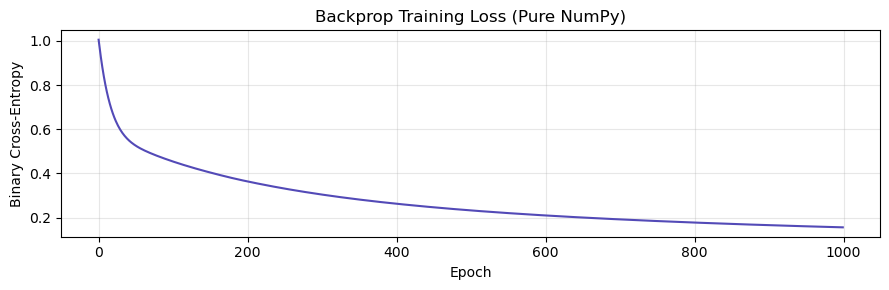

In [11]:
# ── 3.2  Backpropagation Training Loop ────────────────────────────────────────
LR     = 0.05
EPOCHS = 1000
losses = []

for epoch in range(EPOCHS):
    # ── Forward ──
    z1, a1, z2, a2 = forward(X_bp)
    loss = -np.mean(y_bp * np.log(a2 + 1e-9) + (1-y_bp) * np.log(1-a2 + 1e-9))
    losses.append(loss)

    # ── Backward (chain rule) ──
    dL_da2 = -(y_bp / (a2 + 1e-9) - (1-y_bp) / (1-a2 + 1e-9)) / N
    dL_dz2 = dL_da2 * a2 * (1 - a2)          # sigmoid gradient
    dL_dW2 = a1.T @ dL_dz2
    dL_db2 = dL_dz2.sum(axis=0, keepdims=True)

    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * relu_grad(z1)           # ReLU gradient
    dL_dW1 = X_bp.T @ dL_dz1
    dL_db1 = dL_dz1.sum(axis=0, keepdims=True)

    # ── Update weights ──
    W2 -= LR * dL_dW2;  b2 -= LR * dL_db2
    W1 -= LR * dL_dW1;  b1 -= LR * dL_db1

_, _, _, a2_final = forward(X_bp)
final_acc = ((a2_final >= 0.5).astype(float) == y_bp).mean()
print(f'Final loss    : {losses[-1]:.4f}')
print(f'Final accuracy: {final_acc:.4f}')

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(losses, color='#534AB7', linewidth=1.5)
ax.set_title('Backprop Training Loss (Pure NumPy)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Binary Cross-Entropy')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [12]:
# ── 3.3  Numerical Gradient Check ────────────────────────────────────────────
# Verify backprop is correct by comparing with finite differences
eps = 1e-5

def loss_fn(W1_, b1_, W2_, b2_):
    z1_ = X_bp[:5] @ W1_ + b1_
    a1_ = relu(z1_)
    a2_ = sigmoid(a1_ @ W2_ + b2_)
    return -np.mean(y_bp[:5] * np.log(a2_ + 1e-9) + (1-y_bp[:5]) * np.log(1-a2_ + 1e-9))

# Numerical gradient for W2[0,0]
W2_plus  = W2.copy(); W2_plus[0, 0]  += eps
W2_minus = W2.copy(); W2_minus[0, 0] -= eps
num_grad = (loss_fn(W1, b1, W2_plus, b2) - loss_fn(W1, b1, W2_minus, b2)) / (2 * eps)

# Analytical gradient
z1_, a1_, z2_, a2_ = forward(X_bp[:5])
dz2_ = (a2_ - y_bp[:5]) / 5
ana_grad = (a1_.T @ dz2_)[0, 0]

rel_error = abs(num_grad - ana_grad) / (abs(num_grad) + abs(ana_grad) + 1e-12)
print(f'Numerical gradient  : {num_grad:.8f}')
print(f'Analytical gradient : {ana_grad:.8f}')
print(f'Relative error      : {rel_error:.2e}  ← should be < 1e-5')

Numerical gradient  : -0.02835760
Analytical gradient : -0.02835760
Relative error      : 6.74e-10  ← should be < 1e-5


In [13]:
# ── 3.4  SVM: Linear vs Polynomial vs RBF Kernels ────────────────────────────
from sklearn.svm import SVC
from sklearn.datasets import make_moons, make_circles

datasets = {
    'Moons'  : make_moons(n_samples=400, noise=0.15, random_state=42),
    'Circles': make_circles(n_samples=400, noise=0.10, factor=0.5, random_state=42),
}
kernels = ['linear', 'poly', 'rbf']

print('SVM Kernel Comparison:')
for ds_name, (X_ds, y_ds) in datasets.items():
    X_sc = StandardScaler().fit_transform(X_ds)
    print(f'\n  Dataset: {ds_name}')
    for kernel in kernels:
        sc = cross_val_score(SVC(kernel=kernel, C=1.0), X_sc, y_ds, cv=5).mean()
        bar = '█' * int(sc * 20)
        print(f'    {kernel:8s}: {sc:.4f}  {bar}')

SVM Kernel Comparison:

  Dataset: Moons
    linear  : 0.8450  ████████████████
    poly    : 0.8400  ████████████████
    rbf     : 0.9775  ███████████████████

  Dataset: Circles
    linear  : 0.4950  █████████
    poly    : 0.6075  ████████████
    rbf     : 0.9950  ███████████████████


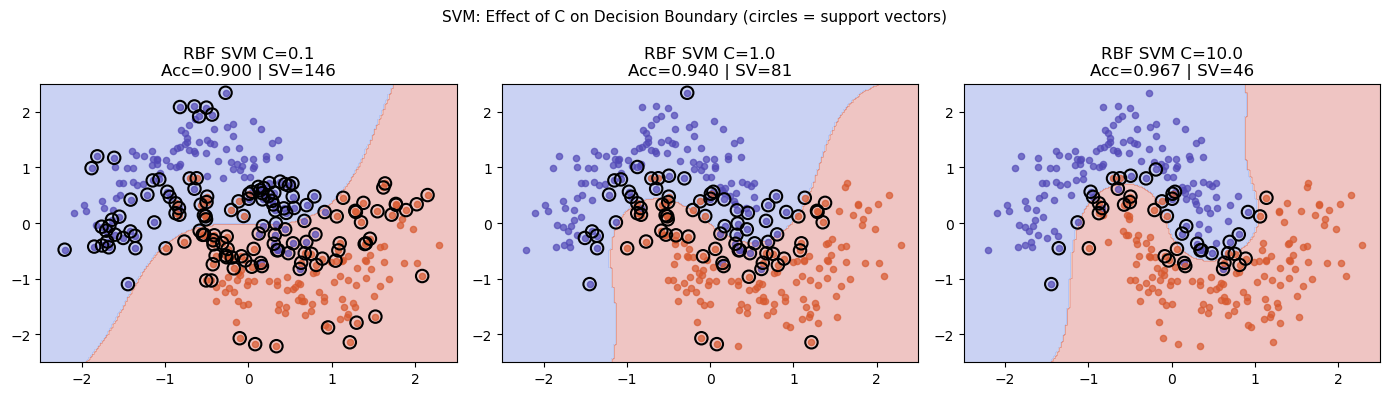

In [14]:
# ── 3.5  SVM Decision Boundary Visualisation ──────────────────────────────────
Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=42)
Xm_sc  = StandardScaler().fit_transform(Xm)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
C_values = [0.1, 1.0, 10.0]

xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200))

for ax, C in zip(axes, C_values):
    svm = SVC(kernel='rbf', C=C).fit(Xm_sc, ym)
    Z   = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(Xm_sc[ym==0, 0], Xm_sc[ym==0, 1], c='#534AB7', s=20, alpha=0.7)
    ax.scatter(Xm_sc[ym==1, 0], Xm_sc[ym==1, 1], c='#D85A30', s=20, alpha=0.7)
    # Highlight support vectors
    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
               s=80, facecolors='none', edgecolors='black', linewidth=1.5)
    acc = svm.score(Xm_sc, ym)
    ax.set_title(f'RBF SVM C={C}\nAcc={acc:.3f} | SV={svm.n_support_.sum()}')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)

plt.suptitle('SVM: Effect of C on Decision Boundary (circles = support vectors)', fontsize=11)
plt.tight_layout(); plt.show()

In [15]:
# ── 5.1  Custom sklearn Transformer ──────────────────────────────────────────
class Winsorizer(BaseEstimator, TransformerMixin):
    """Clip values at p-th and (100-p)-th percentile."""
    def __init__(self, percentile=1):
        self.percentile = percentile

    def fit(self, X, y=None):
        self.lower_ = np.percentile(X, self.percentile, axis=0)
        self.upper_ = np.percentile(X, 100 - self.percentile, axis=0)
        return self

    def transform(self, X):
        return np.clip(X, self.lower_, self.upper_)


class LogTransformer(BaseEstimator, TransformerMixin):
    """Apply log1p to all features (for skewed data)."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.log1p(np.abs(X)) * np.sign(X)


class FeatureDropper(BaseEstimator, TransformerMixin):
    """Drop columns by index."""
    def __init__(self, drop_indices=None):
        self.drop_indices = drop_indices or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        keep = [i for i in range(X.shape[1]) if i not in self.drop_indices]
        return X[:, keep]


# Inject outliers to test Winsorizer
rng = np.random.default_rng(42)
X_out = rng.normal(0, 1, (300, 4))
X_out[0, :] = [100, -100, 50, -50]   # extreme outliers

pipe_w = make_pipeline(Winsorizer(percentile=2), StandardScaler())
X_clean = pipe_w.fit_transform(X_out)

print('Before Winsorising:')
print(f'  Max value: {X_out.max():.1f}  Min value: {X_out.min():.1f}')
print('After Winsorising + Scaling:')
print(f'  Max value: {X_clean.max():.3f}  Min value: {X_clean.min():.3f}')
print('✅ Custom transformers work in sklearn Pipeline')

Before Winsorising:
  Max value: 100.0  Min value: -100.0
After Winsorising + Scaling:
  Max value: 2.154  Min value: -2.307
✅ Custom transformers work in sklearn Pipeline


In [16]:
# ── 5.2  FunctionTransformer for Quick Lambdas ────────────────────────────────
from sklearn.preprocessing import FunctionTransformer

# Quickly wrap any function as a transformer
log_tf      = FunctionTransformer(np.log1p, validate=True)
sqrt_tf     = FunctionTransformer(np.sqrt, validate=True)
abs_log_tf  = FunctionTransformer(lambda X: np.log1p(np.abs(X)), validate=True)

Xw, yw = load_wine(return_X_y=True)
# Proline is highly skewed — log transform helps
proline = Xw[:, -1].reshape(-1, 1)  # last feature

from scipy.stats import skew
print(f'Proline skewness before log : {skew(proline.flatten()):.4f}')
print(f'Proline skewness after log  : {skew(log_tf.fit_transform(proline).flatten()):.4f}')

# Compare accuracy with and without log transform
sc_raw = cross_val_score(
    make_pipeline(StandardScaler(), RandomForestClassifier(50, random_state=42)),
    Xw, yw, cv=5).mean()

# Apply log to all features (they're all positive for wine)
Xw_log = np.log1p(Xw)
sc_log = cross_val_score(
    make_pipeline(StandardScaler(), RandomForestClassifier(50, random_state=42)),
    Xw_log, yw, cv=5).mean()

print(f'\nRandom Forest — without log: {sc_raw:.4f}')
print(f'Random Forest — with log   : {sc_log:.4f}')

Proline skewness before log : 0.7613
Proline skewness after log  : 0.0872

Random Forest — without log: 0.9610
Random Forest — with log   : 0.9610


In [17]:
# ── 5.3  Population Stability Index (PSI) for Drift Detection ─────────────────
def compute_psi(expected, actual, n_bins=10):
    """PSI < 0.1 = stable, 0.1-0.2 = slight drift, > 0.2 = significant drift"""
    breakpoints = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    breakpoints = np.unique(breakpoints)  # remove duplicates

    exp_counts = np.histogram(expected, bins=breakpoints)[0]
    act_counts = np.histogram(actual,   bins=breakpoints)[0]

    exp_pct = exp_counts / len(expected) + 1e-8
    act_pct = act_counts / len(actual)   + 1e-8

    psi_values = (act_pct - exp_pct) * np.log(act_pct / exp_pct)
    return psi_values.sum(), psi_values


rng = np.random.default_rng(42)
# Simulate model score distributions
train_scores = rng.normal(0.70, 0.10, 2000)  # training distribution
no_drift     = rng.normal(0.70, 0.10, 1000)  # same distribution
mild_drift   = rng.normal(0.62, 0.12, 1000)  # slight shift
heavy_drift  = rng.normal(0.45, 0.15, 1000)  # major drift

scenarios = [
    ('No drift',     no_drift),
    ('Mild drift',   mild_drift),
    ('Heavy drift',  heavy_drift),
]

print('PSI Drift Detection Results:')
print(f'{"Scenario":15s} | {"PSI":6s} | Status')
print('-' * 40)
for name, scores in scenarios:
    psi_val, _ = compute_psi(train_scores, scores)
    status = 'Stable' if psi_val < 0.1 else 'Slight drift' if psi_val < 0.2 else 'SIGNIFICANT DRIFT'
    print(f'{name:15s} | {psi_val:.4f} | {status}')

PSI Drift Detection Results:
Scenario        | PSI    | Status
----------------------------------------
No drift        | 0.0217 | Stable
Mild drift      | 0.4486 | SIGNIFICANT DRIFT
Heavy drift     | 2.1917 | SIGNIFICANT DRIFT


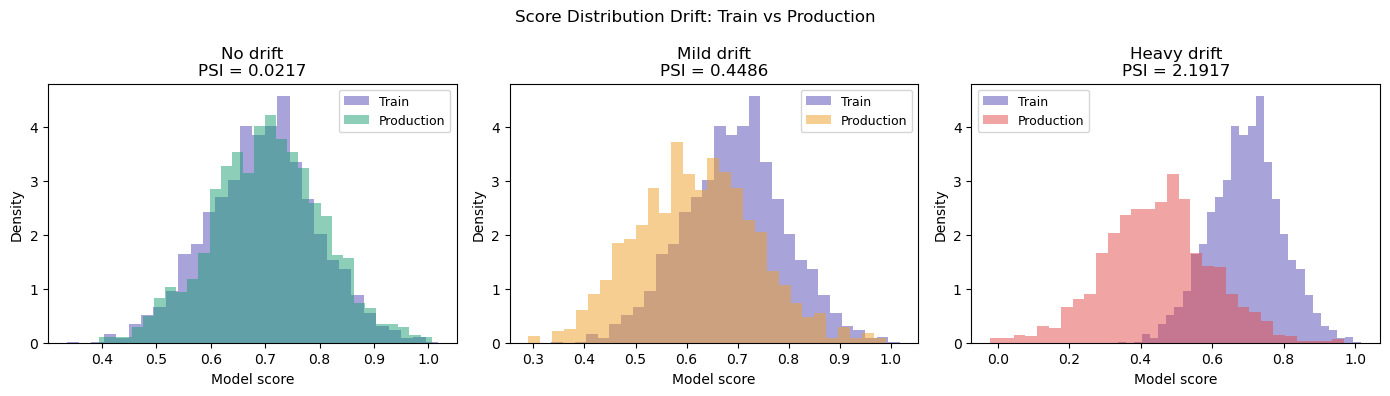

In [18]:
# ── 5.4  Visualise Drift ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_drift = ['#1D9E75', '#EF9F27', '#E24B4A']

for ax, (name, scores), color in zip(axes, scenarios, colors_drift):
    ax.hist(train_scores, bins=30, alpha=0.5, color='#534AB7', label='Train', density=True)
    ax.hist(scores, bins=30, alpha=0.5, color=color, label='Production', density=True)
    psi_val, _ = compute_psi(train_scores, scores)
    ax.set_title(f'{name}\nPSI = {psi_val:.4f}')
    ax.set_xlabel('Model score'); ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Score Distribution Drift: Train vs Production', fontsize=12)
plt.tight_layout(); plt.show()

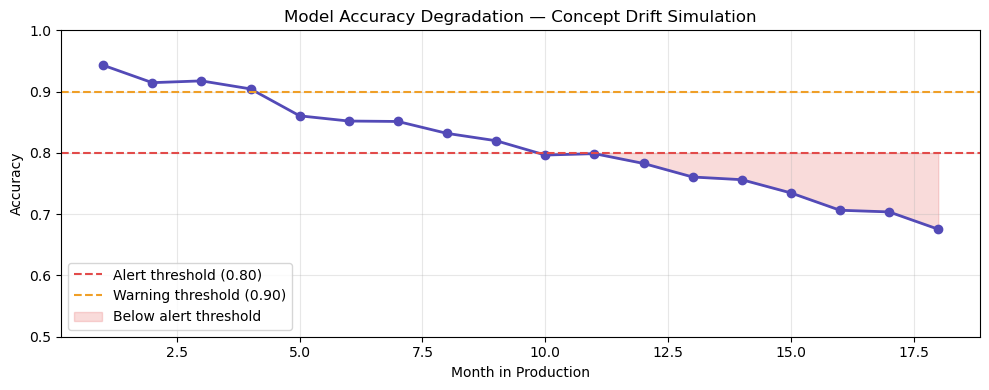

Month 1  accuracy: 0.9430
Month 18 accuracy: 0.6754
Drop: 26.8%


In [19]:
# ── 5.5  Concept Drift Simulation ─────────────────────────────────────────────
# Simulate accuracy degradation as concept drifts over time
rng = np.random.default_rng(42)
n_months    = 18
monthly_acc = []

for month in range(n_months):
    drift = month * 0.015                          # gradual concept drift
    acc   = 0.94 - drift + rng.normal(0, 0.01)     # accuracy degrades
    monthly_acc.append(max(0.5, acc))

fig, ax = plt.subplots(figsize=(10, 4))
months = list(range(1, n_months + 1))
ax.plot(months, monthly_acc, 'o-', color='#534AB7', linewidth=2, markersize=6)
ax.axhline(0.80, linestyle='--', color='#E24B4A', linewidth=1.5, label='Alert threshold (0.80)')
ax.axhline(0.90, linestyle='--', color='#EF9F27', linewidth=1.5, label='Warning threshold (0.90)')

# Shade degraded zone
ax.fill_between(months, monthly_acc, 0.80,
                where=[a < 0.80 for a in monthly_acc],
                alpha=0.2, color='#E24B4A', label='Below alert threshold')

ax.set_title('Model Accuracy Degradation — Concept Drift Simulation')
ax.set_xlabel('Month in Production'); ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.0); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Month 1  accuracy: {monthly_acc[0]:.4f}')
print(f'Month {n_months} accuracy: {monthly_acc[-1]:.4f}')
print(f'Drop: {(monthly_acc[0] - monthly_acc[-1])*100:.1f}%')

In [20]:
# ── 5.6  Structured Prediction Logger ────────────────────────────────────────
import json, time, hashlib
from datetime import datetime

class PredictionLogger:
    def __init__(self, model_name, version='1.0'):
        self.model_name = model_name
        self.version    = version
        self.logs       = []

    def log(self, features, prediction, probability, latency_ms):
        record = {
            'timestamp'    : datetime.utcnow().isoformat(),
            'model'        : self.model_name,
            'version'      : self.version,
            'input_hash'   : hashlib.md5(str(features).encode()).hexdigest()[:8],
            'prediction'   : int(prediction),
            'probability'  : round(float(probability), 4),
            'latency_ms'   : round(latency_ms, 2),
        }
        self.logs.append(record)
        return record

    def summary(self):
        df = pd.DataFrame(self.logs)
        return {
            'total_preds'     : len(df),
            'avg_latency_ms'  : df['latency_ms'].mean().round(2),
            'avg_probability' : df['probability'].mean().round(4),
            'class_counts'    : df['prediction'].value_counts().to_dict(),
        }

# Simulate 10 predictions
iris    = load_iris(as_frame=True)
Xir, yir = iris.data.values, iris.target
model   = GaussianNB().fit(Xir, yir)
logger  = PredictionLogger('iris-gnb', version='2.1')

for i in range(10):
    sample = Xir[i]
    t0     = time.perf_counter()
    pred   = model.predict([sample])[0]
    prob   = model.predict_proba([sample])[0].max()
    lat    = (time.perf_counter() - t0) * 1000
    logger.log(sample.tolist(), pred, prob, lat)

print('Sample log entry:')
print(json.dumps(logger.logs[0], indent=2))
print('\nLogger summary:')
print(json.dumps(logger.summary(), indent=2))

Sample log entry:
{
  "timestamp": "2026-03-27T06:54:46.085899",
  "model": "iris-gnb",
  "version": "2.1",
  "input_hash": "00f4ad59",
  "prediction": 0,
  "probability": 1.0,
  "latency_ms": 0.72
}

Logger summary:
{
  "total_preds": 10,
  "avg_latency_ms": 0.46,
  "avg_probability": 1.0,
  "class_counts": {
    "0": 10
  }
}
